In [2]:
%pip install numpy matplotlib scikit-learn seaborn

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']
# Seperate X and Y (Feature and target)

In [12]:
# Train-Test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
# Initialize and train the KNN model
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [16]:
  print("\n Model Evaluation:")
  print("Accuracy:",accuracy_score(y_test,y_pred))

  print("Classification Report:\n",classification_report(y_test,y_pred))


 Model Evaluation:
Accuracy: 0.6493506493506493
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.71        99
           1       0.51      0.64      0.56        55

    accuracy                           0.65       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.67      0.65      0.66       154



Text(0.5, 1.0, 'Confusion Matrix')

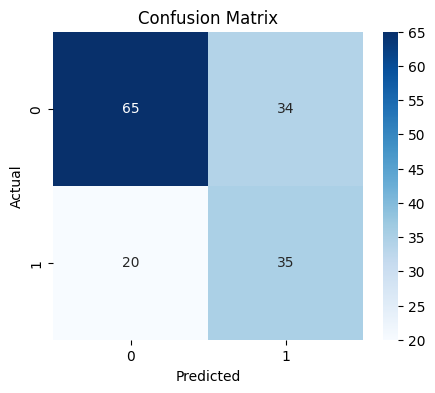

In [18]:
# Step 9 confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

Neighbors 1
Accuracy: 0.6753246753246753
Neighbors 2
Accuracy: 0.7012987012987013
Neighbors 3
Accuracy: 0.6493506493506493
Neighbors 4
Accuracy: 0.7077922077922078
Neighbors 5
Accuracy: 0.6623376623376623
Neighbors 6
Accuracy: 0.7272727272727273
Neighbors 7
Accuracy: 0.6883116883116883
Neighbors 8
Accuracy: 0.7467532467532467
Neighbors 9
Accuracy: 0.7207792207792207
Neighbors 10
Accuracy: 0.7662337662337663
Neighbors 11
Accuracy: 0.7337662337662337
Neighbors 12
Accuracy: 0.7792207792207793
Neighbors 13
Accuracy: 0.7727272727272727
Neighbors 14
Accuracy: 0.7727272727272727
Neighbors 15
Accuracy: 0.7597402597402597
Neighbors 16
Accuracy: 0.7792207792207793
Neighbors 17
Accuracy: 0.7727272727272727
Neighbors 18
Accuracy: 0.7597402597402597
Neighbors 19
Accuracy: 0.7532467532467533
Neighbors 20
Accuracy: 0.7272727272727273


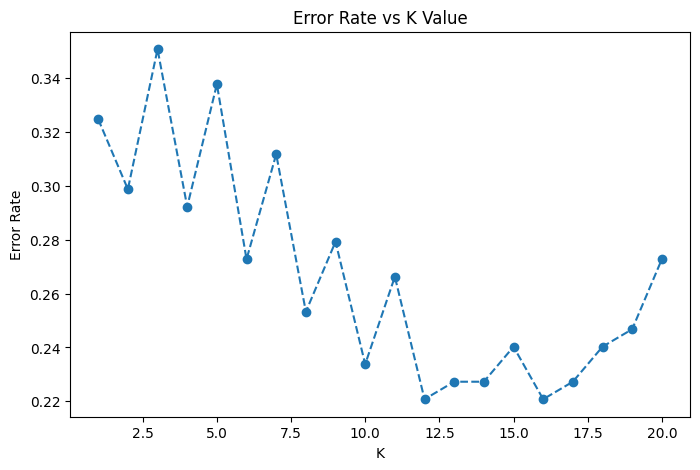

In [22]:
# Step 10:(Optional) Tune 'k' to find the best value
error_rate=[]
for k in range(1,21):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  pred_k=knn.predict(X_test)
  print("Neighbors",k)
  print("Accuracy:",accuracy_score(y_test,pred_k))
  error_rate.append(np.mean(pred_k!=y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,21),error_rate,linestyle='dashed',marker='o')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [23]:
sample=np.array([[2,120,70,25,80,30.5,0.4,35]])
prediction=knn.predict(sample)[0]

if prediction==1:
  print("The person is diabetic")
else:
  print("The person is not diabetic")

The person is not diabetic


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [25]:
%pip install pypickle
import pickle
with open('knn_diabates_model.pkl','wb')as file:
  pickle.dump(knn,file)